# Introduction to Simple Linear Regression
Author: Brad Sheese
---



## Before We Begin...
I'm going to present some information about regression as a refresher. What I've got here is not a substitute for the course readings. Please do the readings.If you haven't previously had a statistics course that covered this material you may need to go beyond the readings and the exercises to get comfortable with regression as a tool. Fortunately, these days there are [all kinds of materials pitched at different audiences to help you out](https://www.youtube.com/results?search_query=simple+linear+regression). Poke around until your find something you like. If you get a bit frustrated, keep at it. If you get really frustrated, come ask for help. That's what we are here for.


## Brief Refresher
 on the BasicsRegression is an approach for modelling a relationship between two (or more) variables. The most basic form of regression looks at the linear association between two continuous variables.Let's say we want to understand the association between the amount of sugar in a drink and its perceived sweetness. A really basic model of the association would be to propose a simple linear model where the more sugar you add, the more perceived sweetness.If we have data with two variables, sugar content and perceived sweetness, we might start to look at their association by looking at their correlation. Specifically, we might look at the Pearson's r. If more sugar leads to more sweet, we should see a positive correlation and a scatterplot that looks something like this.


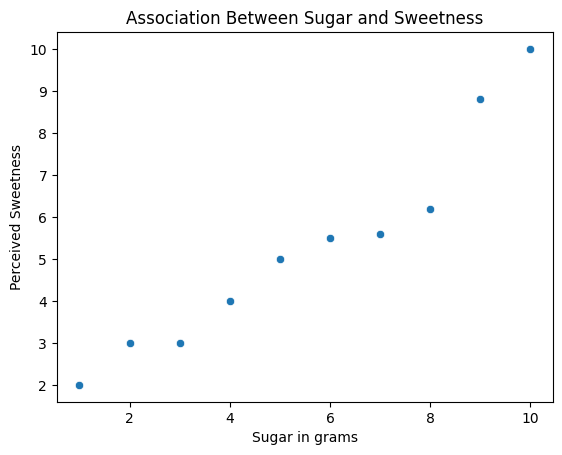

In [1]:
# imports
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# make our data
sugar = np.array([1,2,3,4,5,6,7,8,9,10])
perceived_sweet = np.array([2,3,3,4,5,5.5,5.6,6.2,8.8,10])
studydata = pd.DataFrame(zip(sugar,perceived_sweet), columns = ['sugar','sweet'])

# plot our data
sns.scatterplot(x = 'sugar', y = 'sweet', data = studydata)
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.title('Association Between Sugar and Sweetness')
plt.show()


Note: This is completely made up data. The [relation between sensory stimuli and our perception of that stimuli turns out to be a bit complicated](https://en.wikipedia.org/wiki/Weber%E2%80%93Fechner_law) and not linear. But let's stick with simple for now, we will get back to non-linear models later.The scatterplot plus the correlation seems to have answered our question. Yes, there is a simple linear association between these two variables. As we add more sugar to our drink, there is an increase in the perceived sweetness.A regression model will tell us the same thing, but take it one step farther and allow us to make predictions about data that we don't have. Our experiment stopped at 10 grams of sugar. What if we wanted to use our model to predict the perception of 17 grams or 20 grams? A regression model built with our data would allow us to do that. It will also allow us to look at associations that are much more complex than just a simple linear associations between two variables (more on that later).


## The Linear Regression Model EquationThe formal equation for a simple linear regression model is:$$y = b_0 + b_1 x + e$$Where:- **$y$** is the **outcome** variable (also called the response, dependent variable, or target)- **$x$** is the **predictor** variable (also called the explanatory, independent variable, or feature)- **$b_0$** is the **intercept** — the expected value of $y$ when $x = 0$- **$b_1$** is the **slope** — the expected change in $y$ for each one-unit increase in $x$- **$e$** is the **error** — the part of $y$ that the model doesn't explain (the "leftover" variation)You will also see this written with different notation depending on the field:| Field | Equation ||
---
|
---
|| Machine Learning | $\text{outcome} = \text{bias} + (\text{scale\_factor} \times \text{feature}) + \text{error}$ || Sciences | $\text{dependent} = \text{intercept} + (\text{slope} \times \text{independent}) + \text{error}$ || Statistics (population) | $Y = \beta_0 + \beta_1 X + \epsilon$ || Statistics (sample) | $y = b_0 + b_1 x + e$ |### Population Parameters vs. Sample StatisticsThe Greek letters $\beta_0$ and $\beta_1$ represent the **true population parameters** — the actual intercept and slope that describe the relationship for the entire population we care about. We almost never know these values.The values $b_0$ and $b_1$ are **sample statistics** — estimates of the population parameters calculated from our observed data. They are **point estimates** of $\beta_0$ and $\beta_1$.Think of it this way: if we collected a different sample of sugar/sweetness data, we would get slightly different $b_0$ and $b_1$ values. Each sample gives us a different estimate of the true population relationship. We will return to this idea when we discuss inference for regression later in the course.


## Perfect vs. Imperfect vs. Non-Linear Relationships### Perfect Linear RelationshipIn a perfect linear relationship, knowing $x$ gives you the exact value of $y$. Every single data point falls exactly on the line. This is extremely rare in natural processes.An example: the total cost of purchasing shares of stock. If one share costs $64.96, then 1 share costs $64.96, 2 shares cost $129.92, etc. The relationship is perfectly determined by the formula: $\text{total cost} = 5 + 64.96 \times \text{number of shares}$. (The $5 is a fixed transaction fee — the intercept.)


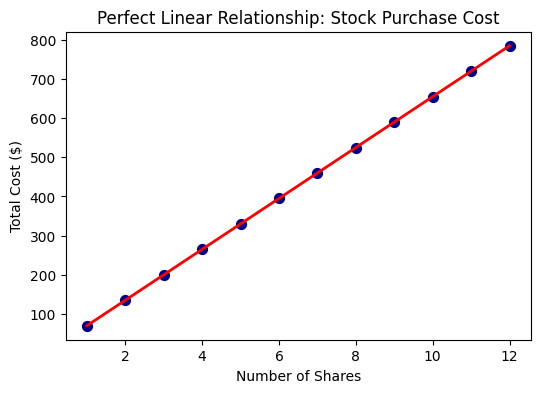

Correlation: 1.0000


In [2]:
# perfect linear relationship
shares = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
cost = 5 + 64.96 * shares

plt.figure(figsize=(6, 4))
plt.scatter(shares, cost, color='darkblue', s=50)
plt.plot(shares, cost, color='red', linewidth=2)
plt.xlabel('Number of Shares')
plt.ylabel('Total Cost ($)')
plt.title('Perfect Linear Relationship: Stock Purchase Cost')
plt.show()

print(f"Correlation: {np.corrcoef(shares, cost)[0,1]:.4f}")


### Imperfect Linear RelationshipsThis is what we encounter almost all the time. The data form a "cloud of points" that cluster around a line, but no observation (or very few) fall exactly on it. There is a real linear trend, but other factors also influence the outcome.The sugar/sweetness data above is an imperfect linear relationship — there is a clear upward trend, but the points don't fall perfectly on a line.


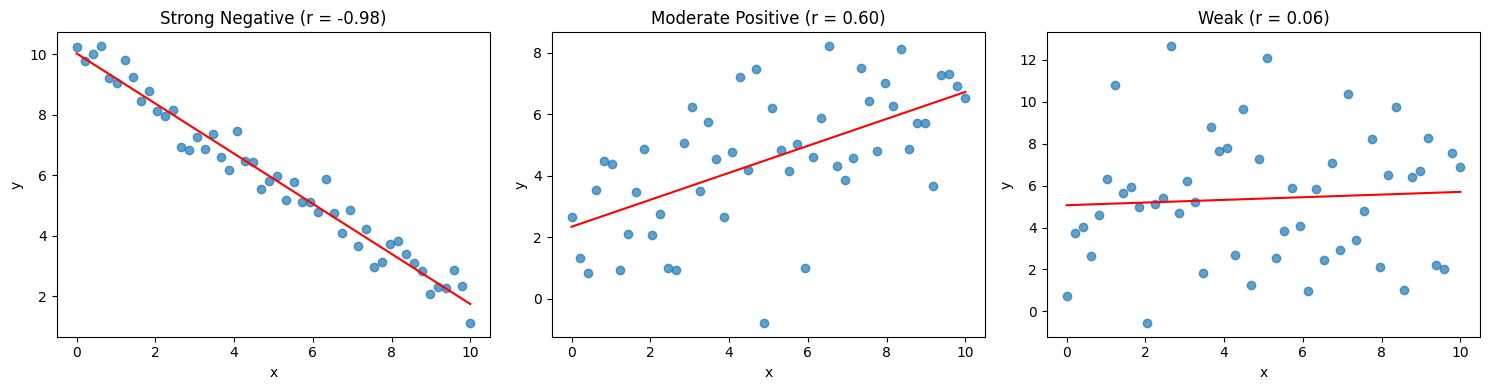

In [3]:
# three imperfect linear relationships
np.random.seed(42)
x = np.linspace(0, 10, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# strong negative
y1 = 10 - 0.8 * x + np.random.normal(0, 0.5, 50)
axes[0].scatter(x, y1, alpha=0.7)
axes[0].plot(x, np.polyval(np.polyfit(x, y1, 1), x), color='red')
axes[0].set_title(f'Strong Negative (r = {np.corrcoef(x, y1)[0,1]:.2f})')

# moderate positive
y2 = 2 + 0.5 * x + np.random.normal(0, 2, 50)
axes[1].scatter(x, y2, alpha=0.7)
axes[1].plot(x, np.polyval(np.polyfit(x, y2, 1), x), color='red')
axes[1].set_title(f'Moderate Positive (r = {np.corrcoef(x, y2)[0,1]:.2f})')

# weak
y3 = 5 + 0.1 * x + np.random.normal(0, 3, 50)
axes[2].scatter(x, y3, alpha=0.7)
axes[2].plot(x, np.polyval(np.polyfit(x, y3, 1), x), color='red')
axes[2].set_title(f'Weak (r = {np.corrcoef(x, y3)[0,1]:.2f})')

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()


### Non-Linear RelationshipsSometimes there is a very clear relationship between two variables, but it is **not linear**. Fitting a straight line to non-linear data is not helpful — the "best" straight line may be nearly flat, telling us nothing useful about the relationship.An example from physics: the distance a ball travels when rolled down a ramp depends on the angle of the ramp, but the relationship is quadratic (curved), not linear.


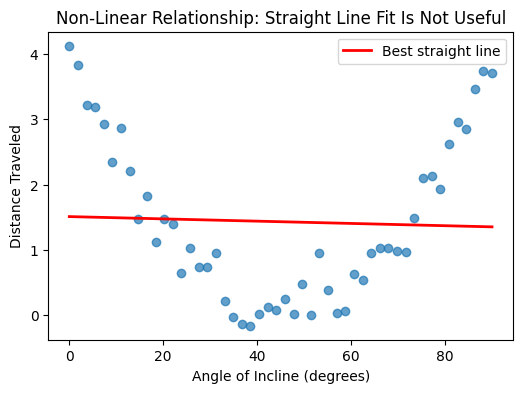

Correlation: -0.037
The correlation is near zero even though the variables are clearly related!


In [4]:
# non-linear relationship
angle = np.linspace(0, 90, 50)
distance = 0.002 * (angle - 45)**2 + np.random.normal(0, 0.3, 50)

plt.figure(figsize=(6, 4))
plt.scatter(angle, distance, alpha=0.7)

# overlay the "best" straight line
slope, intercept = np.polyfit(angle, distance, 1)
plt.plot(angle, slope * angle + intercept, color='red', linewidth=2, label='Best straight line')
plt.xlabel('Angle of Incline (degrees)')
plt.ylabel('Distance Traveled')
plt.title('Non-Linear Relationship: Straight Line Fit Is Not Useful')
plt.legend()
plt.show()

print(f"Correlation: {np.corrcoef(angle, distance)[0,1]:.3f}")
print("The correlation is near zero even though the variables are clearly related!")


## Visualizing a Linear ModelBefore we build the model, let's go back to visualizing the association. Seaborn has a pretty straightforward way of producing a visualization of a simple linear model.


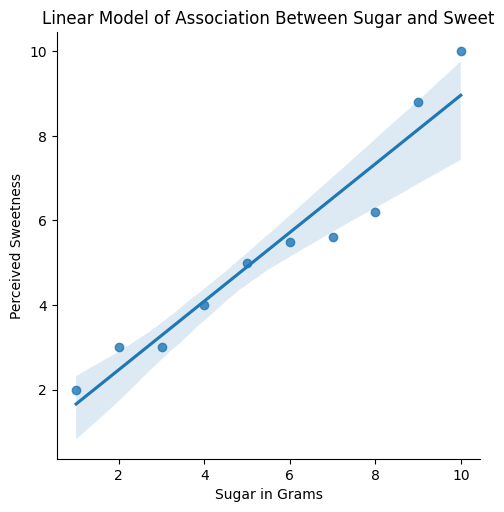

In [5]:
sns.lmplot(x='sugar', y='sweet', data=studydata)
plt.xlabel('Sugar in Grams')
plt.ylabel('Perceived Sweetness')
plt.title('Linear Model of Association Between Sugar and Sweet')
plt.show()


Understanding elements of the regression plot:* **Dots**: The dots are individual data points. The same that we would see with a scatter plot.* **Line**: That dark blue line is a linear model that has been 'fit' to those points. You can think of it as the best straight line path through the data.* **Shaded Area**: Seaborn also provides the shaded area around the line that gives us an idea of how much uncertainty there is in our prediction along that line. The uncertainty is related to how many data points we have and how spread out those points are.


## Visualizing UncertaintySeaborn also provides the shaded area around the line that gives us an idea of how much uncertainty there is in our prediction along that line. The uncertainty is related to how many data points we have and how spread out those points are. We will talk more about uncertainty in class.For now, let's just look at how the shaded area changes depending on the data we've got. The data below has more spread to it that the data we used before, so the next visualization has a wider shaded area indicating more uncertainty about our model's predictions.


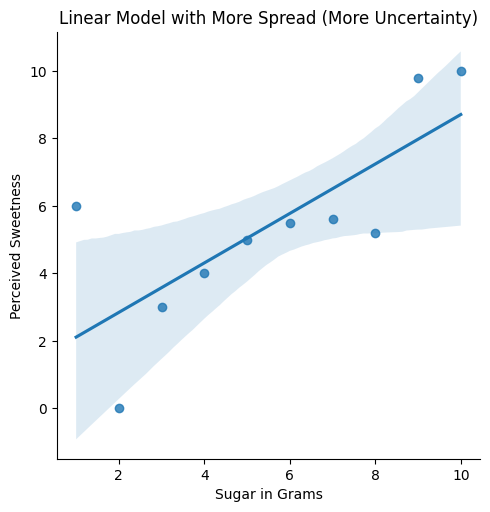

In [6]:
# make our data
sugar = np.array([1,2,3,4,5,6,7,8,9,10])
perceived_sweet = np.array([6,0,3,4,5,5.5,5.6,5.2,9.8,10])
studydata2 = pd.DataFrame(zip(sugar,perceived_sweet), columns = ['sugar','sweet'])

# plot our data
sns.lmplot(x = 'sugar', y = 'sweet', data = studydata2)
plt.xlabel('Sugar in Grams')
plt.ylabel('Perceived Sweetness')
plt.title('Linear Model with More Spread (More Uncertainty)')
plt.show()


In the data below we have ten times as many data points and the uncertainty is reduced. The data is also distributed fairly uniformly along the regression line.


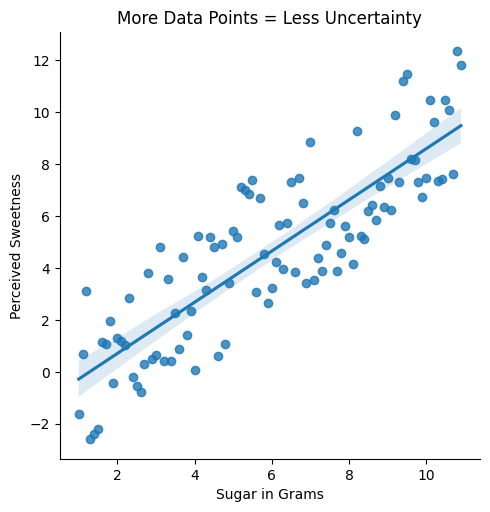

In [7]:
# make our data
sugar = np.arange(1,11,0.1)
perceived_sweet = np.array([(x/10)+random.uniform(-3,3) for x in range(100)])
studydata3 = pd.DataFrame(zip(sugar,perceived_sweet), columns = ['sugar','sweet'])

# plot our data
sns.lmplot(x = 'sugar', y = 'sweet', data = studydata3)
plt.xlabel('Sugar in Grams')
plt.ylabel('Perceived Sweetness')
plt.title('More Data Points = Less Uncertainty')
plt.show()


You should remember that just because we can make a regression model and draw a line does not mean that the model is making useful predictions. If we have two completely unassociated variables, the regression model will wind up using the mean of one variable to predict the other. For example, the code below looks at the association between sugar and sweetness when both are randomly generated and completely unrelated. Five graphs are generated, and at least a few of the lines you see in them may look like its telling your something meaningful. Run the cell a few times. Randomness can give us some pretty convincing non-sense trends. This is an important issue in statistics and in machine learning.


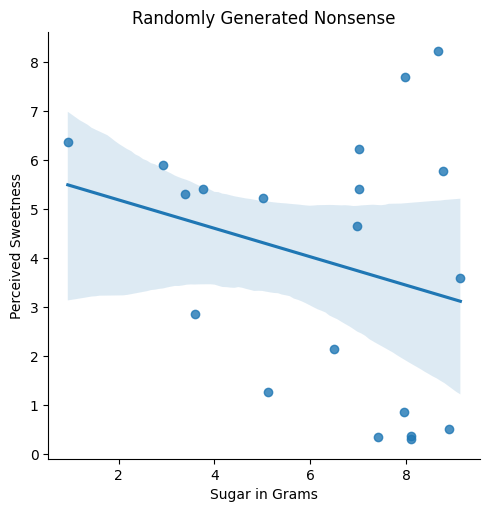

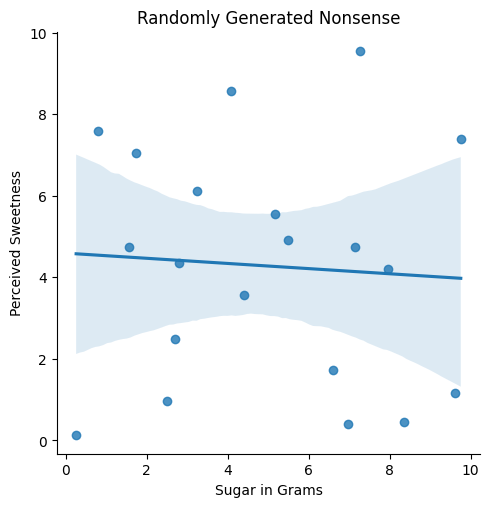

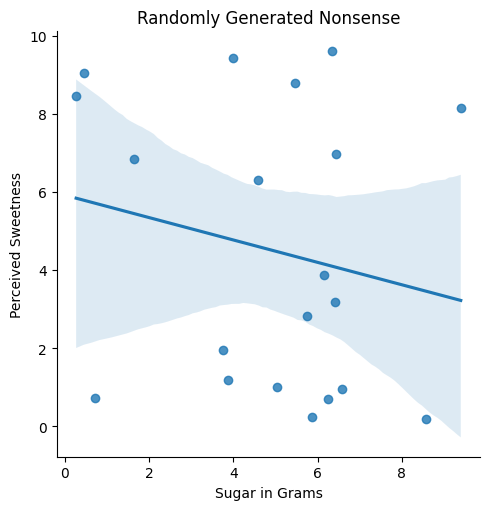

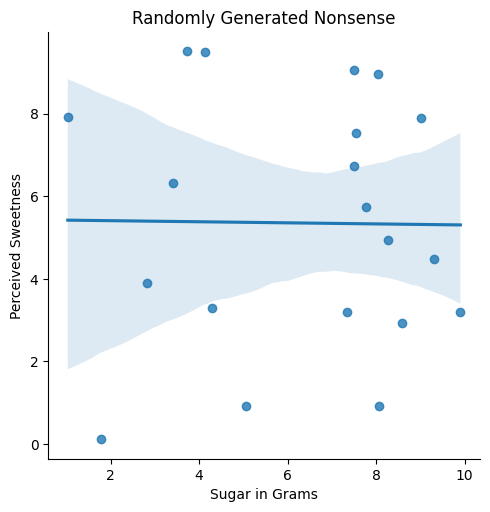

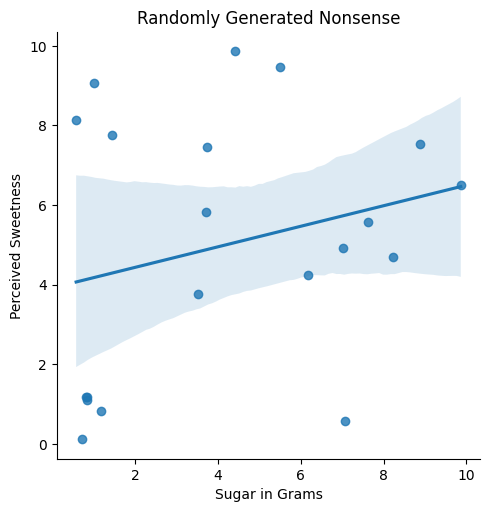

In [8]:
# run this cell and then review the plots below
for randomplot in range(5):
  # make our data
  sugar = np.random.rand(20) * 10
  perceived_sweet = np.random.rand(20) * 10
  studydata = pd.DataFrame(zip(sugar,perceived_sweet), columns = ['sugar','sweet'])

  # plot our data
  sns.lmplot(x = 'sugar', y = 'sweet', data = studydata)
  plt.xlabel('Sugar in Grams')
  plt.ylabel('Perceived Sweetness')
  plt.title('Randomly Generated Nonsense')
  plt.show()


So beware interpreting just any regression line you can make. After you build the model and draw the line you still need to do a bit more to understand whether or not your model captures anything meaningful about the data. Often, the model will reveal that there is not a meaningful relation between the variables.


## Predictions Are Averages, Not CertaintiesWhen a regression model predicts $\hat{y} = 88.2$ for a possum with 80 cm total length, this does **not** mean every 80 cm possum has a head length of exactly 88.2 mm. It means that, **on average**, possums with 80 cm total length have head lengths around 88.2 mm. Individual possums will vary above and below this prediction.The regression line represents the **expected (average) outcome** for any given value of $x$. The spread of points around the line represents the natural variation that remains even after accounting for the linear relationship.This is why the shaded uncertainty band in Seaborn's `lmplot` matters — it shows us the range of plausible values for the *average* outcome at each $x$ value. Wider band = more uncertainty about where the true average lies.


## Looking at Relationships by Group or CategoryThere may be other variables that could help us understand the relationship between a predictor and an outcome. For example, the relationship between total length and head length of possums might differ for males vs. females, or for possums from different regions of Australia.We can explore this by coloring our scatterplot by a third variable. This doesn't change the regression model itself — it just helps us see whether the relationship might be different across groups. If the groups show clearly different patterns, that suggests we might want to include that third variable in our model (which we will learn to do in the multiple regression chapter).Below we create a fabricated example using our sugar/sweetness data, adding a "drink type" variable.


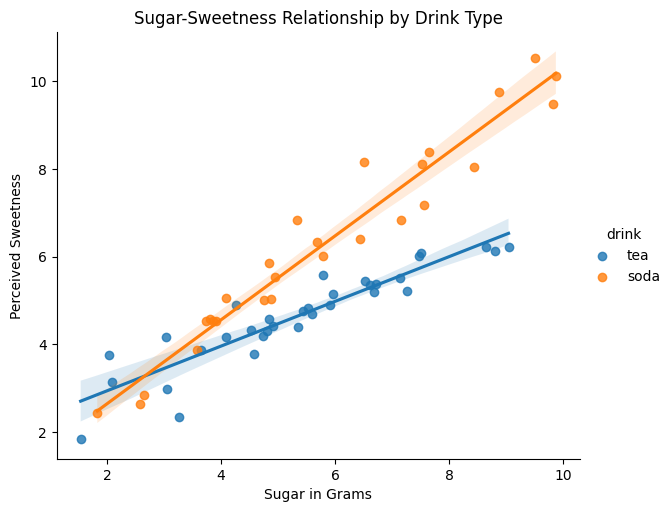

Notice: the two drink types appear to have different slopes and intercepts.
This suggests that drink type might matter for predicting sweetness.
We will learn how to include multiple predictors in a later chapter.


In [9]:
# fabricated data with a third categorical variable
np.random.seed(123)
n = 60
sugar_all = np.random.uniform(1, 10, n)
drink_type = np.random.choice(['soda', 'tea'], n)

# soda: steeper relationship, tea: shallower
sweet_all = np.where(
    drink_type == 'soda',
    1.0 + 0.9 * sugar_all + np.random.normal(0, 0.5, n),
    2.0 + 0.5 * sugar_all + np.random.normal(0, 0.5, n)
)

df_grouped = pd.DataFrame({'sugar': sugar_all, 'sweet': sweet_all, 'drink': drink_type})

# plot with hue
sns.lmplot(x='sugar', y='sweet', hue='drink', data=df_grouped, height=5, aspect=1.2)
plt.xlabel('Sugar in Grams')
plt.ylabel('Perceived Sweetness')
plt.title('Sugar-Sweetness Relationship by Drink Type')
plt.show()

print("Notice: the two drink types appear to have different slopes and intercepts.")
print("This suggests that drink type might matter for predicting sweetness.")
print("We will learn how to include multiple predictors in a later chapter.")


## Summary:
 Regression Compared to Correlation**How are regression and correlation similar?*** They both look at the associations between variables* They both tell us the direction and strength of an association**How do they differ? What do we get out of a regression model that we don't get out of a correlation statistic and a scatterplot?*** The ability to make predictions for unobserved values* The ability to examine variations in uncertainty along the regression line* The ability to extend regression to look at more than two variables at a time, and to look at non-linear associations**Key concepts introduced in this notebook:*** The model equation: $y = b_0 + b_1 x + e$* **Predictor** ($x$) vs. **outcome** ($y$) terminology* **Population parameters** ($\beta_0, \beta_1$) vs. **sample statistics** ($b_0, b_1$)* Perfect vs. imperfect vs. non-linear relationships* Predictions represent **averages**, not certainties* Coloring by a third variable can reveal group differences that motivate multiple regressionRegression isn't always a better tool for examining associations. Correlation has some advantages over regression in some circumstances. However, in machine learning, where we often want to predict a single outcome using multiple predictors or 'features', regression will be the go-to tool for building simple models.

**In the next notebook (17.1.1)**, you will build a Simple Linear Regression model from scratch to understand the math behind the "best fit" line.
